# Interesting anomalies from clustering

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from astroExplain.spectra import clustering
from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx
meta = MetaData()

# Custom functions

## Top ranked anomalies

In [2]:
def get_sdss_spec_img(
    specobjid, ra, dec, fname_prefix, save_to
    ):
    """Download sdss image and spectrum"""

    meta.download_sdss_spectrum_image(
        specobjid=specobjid,
        save_to=save_to,
        image_format="jpeg",
        fname_prefix=fname_prefix
    )

    meta.get_sdss_image(
        specobjid,
        coordinates= (ra, dec),
        save_to=save_to,
        image_format="jpeg",
        fname_prefix=fname_prefix
    )

def obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=True,
    save_photometry_to= "./",
    n_top_ranked=20,
):

    n_anomalies_in_cluster = cluster_df.shape[0]
    print(f"Number of anomalies in cluster: {n_anomalies_in_cluster}")

    objd_id_dict = {}

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break

        fname_prefix = f"rank_{anomaly_rank + 1:02d}"
        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = cluster_df.index[anomaly_idx]

        objd_id_dict[anomaly_rank] = specobjid

        if donwload_images is True:
            ra, dec = cluster_df[['ra', 'dec']].loc[specobjid].values
            get_sdss_spec_img(
                specobjid,
                ra, dec,
                save_to=save_photometry_to,
                fname_prefix=fname_prefix
            )
    return objd_id_dict

## Spec with thumbnails

In [3]:
def spec_photo_thumbnail(
    ax,
    wave, spec,
    photo_img=None,
    width_height_image='100%',
    bbox_to_anchor=(0.665, 0.51, 0.5, 0.5),
    # loc="upper right",
    add_image=False,
):

    ax.plot(wave, spec, color='black')
    # Create inset in top-right corner of figure

    ax.set_xlim(350, 770)
    wave_ticks = list(np.arange(400, 751, 50))
    ax.set_xticks(wave_ticks)

    if add_image is False:
        return ax, None

    axins = inset_axes(
        ax,
        width=width_height_image, height=width_height_image,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,
        # loc=loc
    )

    # Show image in the inset
    axins.imshow(photo_img)
    axins.axis('off')  # Hide axis around the image

    return ax, axins


## Lines indicators

In [4]:
GALAXY_LINES_NM = {
    'OII': {'name': 'OII', 'line_wave': 372.7},
    # 'NeIII': {'name': 'NeIII', 'line_wave': 386.9},
    # 'HI': {'name': 'HI', 'line_wave': 388.9},
    'H_epsilon': {'name': r'H$\epsilon$', 'line_wave': 397},
    'H_delta': {'name': r'H$\delta$', 'line_wave': 410.2},
    'H_gamma': {'name': r'H$\gamma$', 'line_wave': 434.0},
    'H_beta': {'name': r'H$\beta$', 'line_wave': 486.1},
    'OIII': {'name': 'OIII', 'line_wave': 500.7},
    'H_alpha': {'name': r'H$\alpha$', 'line_wave': 656.3},
    'SII': {'name': 'SII', 'line_wave': 673},
    # 'SII': 671.6
}

def add_line_indicators(
    ax, wave, spec,
    indicator_starts,
    indicator_height,
    add_ne3_he1=False,
    add_h_epsilon=False,
    add_h_delta=False,
    add_h_gamma=False,
    add_h_beta=False,
    add_sii=False,
    delta=1,
    indicator_color='blue',
    indicator_label_color='black',
    lw=1,
    fontsize=6,
):
    
    for line_name, value_dict in GALAXY_LINES_NM.items():
        
        # skip desired lines
        if line_name == 'H_epsilon' and add_h_epsilon is False:
            continue

        if line_name == 'H_delta' and add_h_delta is False:
            continue

        if line_name == 'H_gamma' and add_h_gamma is False:
            continue

        if line_name == 'H_beta' and add_h_beta is False:
            continue

        if line_name == 'SII' and add_sii is False:
            continue

        line_wave = value_dict['line_wave']
        # Find the flux value of the spectrum at the line's wavelength
        # get small neigborhood among line_wave
        # get max flux there and set as line_flux
        line_flux = np.max(
            spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
        )

        # Plot vertical line indicator
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        ax.plot(
            [line_wave, line_wave], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        
        clean_name = value_dict['name']

        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            line_wave, 
            y_text_start, 
            clean_name,
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

        # doubles manual setup
        if line_name == 'OIII':
            ax.plot(
                [495.9, 495.9], 
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

        if line_name == 'H_alpha':

            y_nii_start = y_start_indicator - indicator_height/2
            y_nii_end = y_end_indicator - indicator_height/2

            # NII 1st
            ax.plot(
                [654.8, 654.8],
                [y_nii_start, y_nii_end],
                color=indicator_color, lw=lw
            )
            y_nii_text = y_nii_end + indicator_height/2
            ax.text(
                649, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

            # NII 2nd
            ax.plot(
                [658.3, 658.3], 
                [y_nii_start, y_nii_end], 
                color=indicator_color, lw=lw
            )

            ax.text(
                664.1, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

        if line_name == 'SII':
            ax.plot(
                [671.6, 671.6],
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

    # optionally add NeIII-1 and He I
    if add_ne3_he1 is True:

        line_flux = np.max(
            spec[(wave > 386.9 - delta) & (wave < 388.9 + delta)]
        )
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        # add indicator for NeIII 386.9
        ax.plot(
            [386.9, 386.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add indicator for HI 388.9
        ax.plot(
            [388.9, 388.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add label NeIII + He I
        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            387.9, 
            y_text_start, 
            'NeIII + HeI',
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

    return ax

# Directories

In [5]:
bin_id = "bin_03"
phd_dir = "/home/elom/phd/00_phd_code"
spectra_dir = f"{phd_dir}/spectra"
kmeans_model_dir = (
    f"{phd_dir}/clustering/{bin_id}/mse_noRel100/"
    "kmeans_top_1_percent_7_clusters_20250514144513_uniform_150_scale_0.9"
)
paper_dir = (
    "/home/elom/gdrive/career/portfolio/phd/"
    "00_paper_explain-me-why/submission"
)
submission_dir = "/home/elom/phd/00_paper_explain-me-why/submission"


# Data ingestion

In [6]:
spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)
idx_id_bin_03 = np.load(
    f"{spectra_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
# convert from angstrom to nanometer
wave /= 10.0

# Load clusters and anomalies metadata

In [7]:
n_spec_bin_03 = 181_850
n_top_1_percent = int(n_spec_bin_03 * 0.01)
n_top_5_percent = int(n_spec_bin_03 * 0.05)
n_top_1_percent, n_top_5_percent
# n_top_1_percent = 180

(1818, 9092)

In [8]:
top_1_percent_df = pd.read_csv(
    f"{kmeans_model_dir}/"
    f"top_1_percent_anomalies.csv.gz",
    # compression="gzip",
    index_col="specobjid"
)

top_1_percent_df.shape,
top_1_percent_df.columns

Index(['mjd', 'plate', 'fiberid', 'run2d', 'ra', 'dec', 'z', 'zErr',
       'zWarning', 'class', 'subClass', 'z_noqso', 'zErr_noqso',
       'zWarning_noqso', 'targetType', 'programname', 'instrument', 'snMedian',
       'ABSSB', 'BROAD', 'ebv', 'score', 'cluster'],
      dtype='object')

# Cluster 1 Galaxies

In [9]:
# get IDs
cluster_id = 1

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()

save_to = !pwd
save_to = save_to[0]

obj_id_cluster_1_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=save_to,
    n_top_ranked=20,
)
# obj_id_cluster_1_dict

Number of anomalies in cluster: 617


## 1. **rank_01**

In [10]:
save_to = !pwd
save_cluster_1_to = f"{save_to[0]}/ranked_anomalies/cluster_1"

In [11]:
rank = 1
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)
# add title
ax.set_title(f"Rank {rank}")
# save figure
# fig.savefig(
#     f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
#     bbox_inches='tight'
# )
# fig.savefig(
#     f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
#     bbox_inches='tight'
# )

NameError: name 'spec_photo_thumbnail_line_indicators' is not defined

## 2. **rank_05**

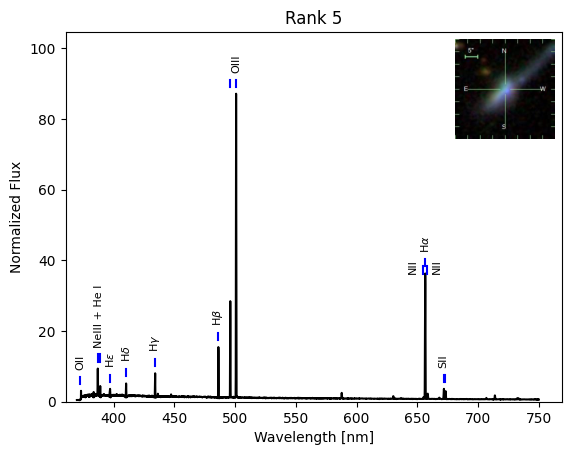

In [75]:
rank = 5
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_18**

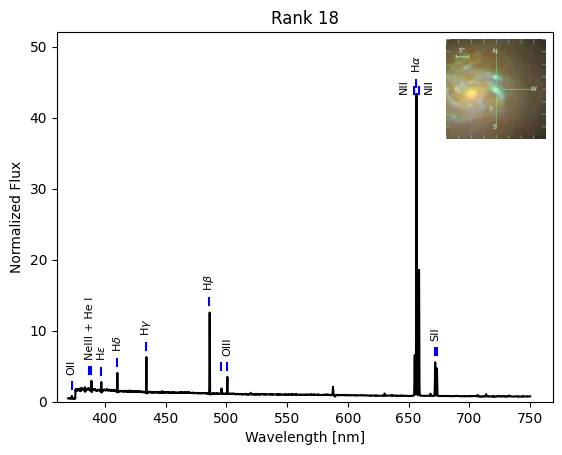

In [77]:
rank = 18
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,

)
# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_02**

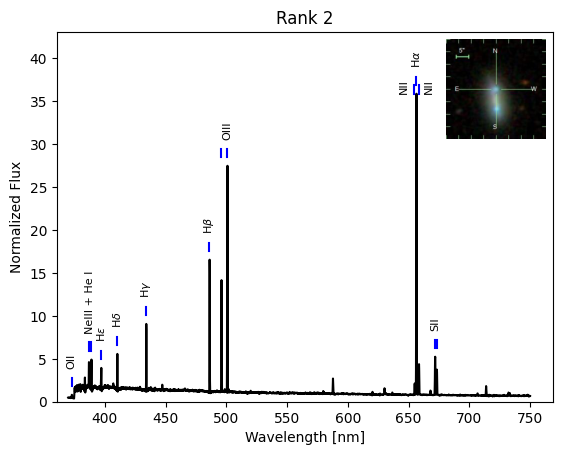

In [78]:
rank = 2
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## Summary

This set of six galaxies is a strong choice because it's not just the six most anomalous, but a **diverse sample** that highlights different physical phenomena: a disturbed spiral, a compact starburst, a merger remnant, an interacting pair, an active merger, and a clumpy disk. This effectively showcases the range of "interesting" objects your method is capable of finding within a single cluster. 👍

# Cluster 2 Galaxies

From clustering analysis this cluster is expected to be more morphologically diverse, with a mix of spirals and compact galaxies, some of which appear inclined or edge-on.

This selection focuses on showcasing the various types of gravitational interactions and resulting morphologies that characterize the anomalies in this cluster.

In [24]:
# get IDs
cluster_id = 2

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()

save_to = !pwd
save_to = save_to[0]

obj_id_cluster_2_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=f"{save_to}/ranked_anomalies/cluster_2_photometry",
    n_top_ranked=20,
)
# obj_id_cluster_2_dict

Number of anomalies in cluster: 287


In [25]:
save_to = !pwd
save_cluster_2_to = f"{save_to[0]}/ranked_anomalies/cluster_2"

## 1. **rank_08**

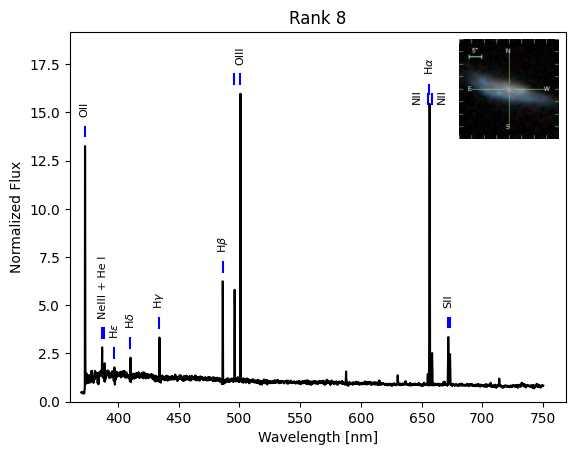

In [87]:
rank = 8
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 2. **rank_11**


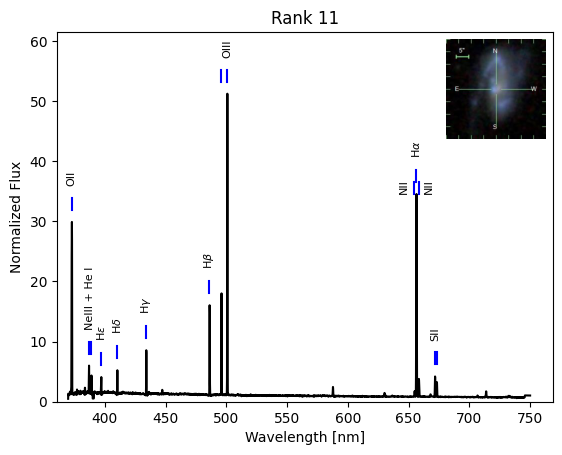

In [88]:
rank = 11
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_14**

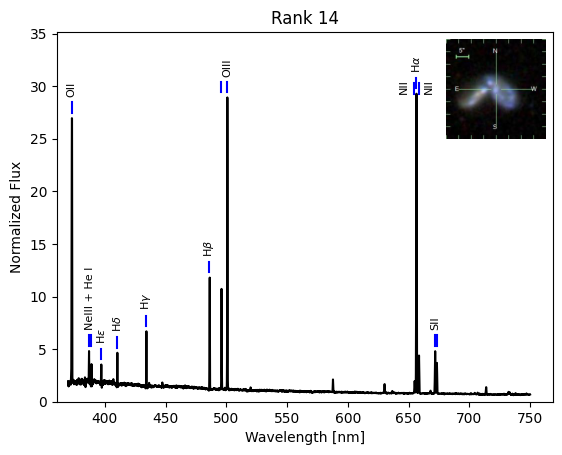

In [89]:
rank = 14
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1.5,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_07**

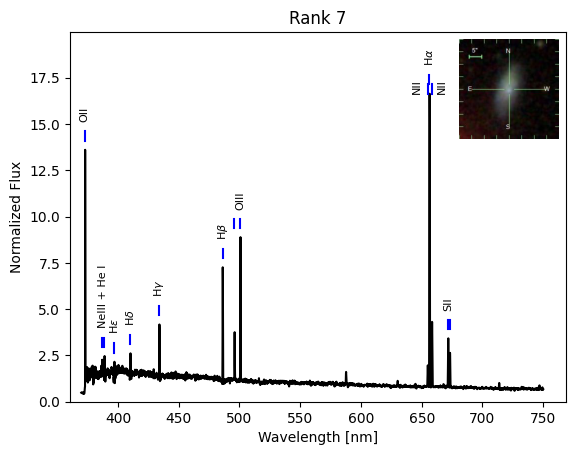

In [98]:
rank = 7
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## Summary

This collection beautifully illustrates the dominant theme of **Cluster 2**: galaxies whose anomalous spectral features are linked to morphological disturbances from gravitational interactions. You have examples spanning the entire merger sequence: an early interaction (`rank_05`), a warped disk from a past encounter (`rank_08`), a chaotic ongoing merger (`rank_11`), a post-merger with tidal tails (`rank_14`), and a tadpole from a minor merger (`rank_07`). This is a very compelling and diverse set.

# Galaxies from Cluster 3

From cluster analysis, this cluster isolates the most extreme, low-metallicity emission-line galaxies, which often have compact, blue morphologies similar to "Green Pea" analogs. The provided images strongly support this, showing a remarkable collection of intensely star-forming and often disturbed systems.

This selection highlights the key features of Cluster 3: compact, high-surface-brightness cores, signs of mergers, and intense, blue star formation.


In [26]:
# get IDs
cluster_id = 3

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()

save_to = !pwd
save_to = save_to[0]

obj_id_cluster_3_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=save_to,
    n_top_ranked=20,
)
# obj_id_cluster_3_dict

Number of anomalies in cluster: 340


In [27]:
save_to = !pwd
save_cluster_3_to = f"{save_to[0]}/ranked_anomalies/cluster_3"

## 1. **rank_01**
* **Reason for Selection:** Top-ranked object that combines a compact core with merger features.

* **Justification:** This galaxy is the quintessential object for this cluster. It has an exceptionally bright and compact blue core, consistent with an extreme starburst, while also displaying faint, wispy tidal features in its outer regions. It perfectly illustrates that these powerful events are often linked to gravitational disturbances.

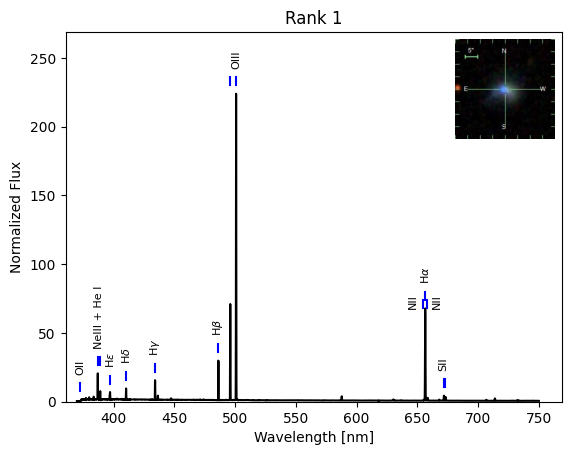

In [93]:
rank = 1
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=6,
    indicator_height=12.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 2. **rank_05**

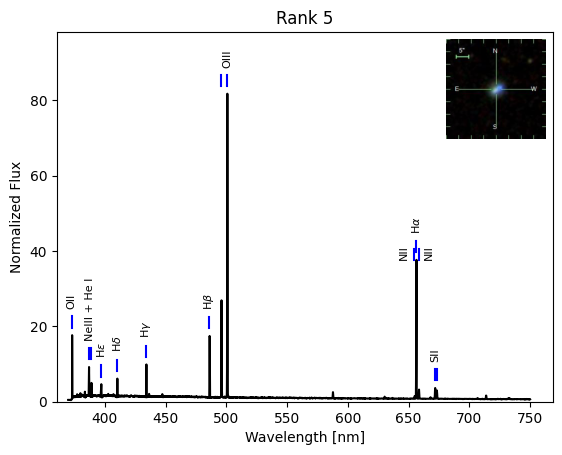

In [94]:
rank = 5
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=5.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_09**

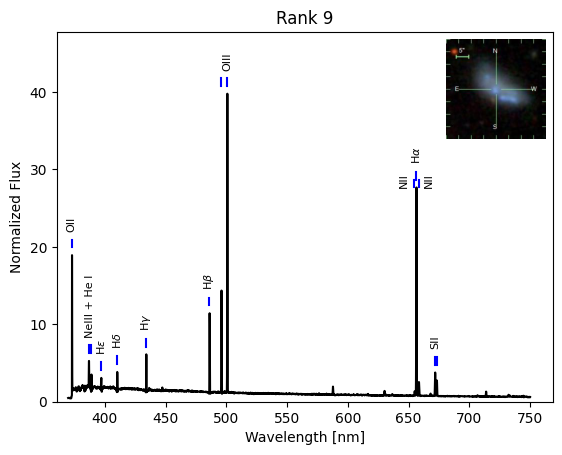

In [95]:
rank = 9
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_19**

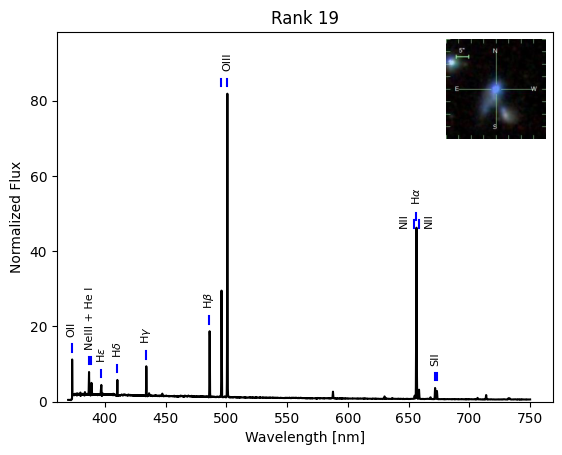

In [99]:
rank = 19
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1,
    add_ne3_he1=True,
)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

# All galaxies

In [12]:
working_directory = !pwd
working_directory = working_directory[0]

## fig settings

In [73]:
height = 3.5
figsize = (2.5*height, height)
width_height_image = '100%'
bbox_to_anchor=(0.765, 0.675, 0.35, 0.35)

## Cluster 1 data

In [13]:
rank = 1
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r1_c1_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
r1_c1_img = mpimg.imread(f"{image_dir}/{image_name}")
 

In [14]:
rank = 5
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r5_c1_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
r5_c1_img = mpimg.imread(f"{image_dir}/{image_name}")

In [15]:
rank = 18
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r18_c1_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
r18_c1_img = mpimg.imread(f"{image_dir}/{image_name}")

In [16]:
rank = 2
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r2_c1_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
r2_c1_img = mpimg.imread(f"{image_dir}/{image_name}")

## Plot cluster 1

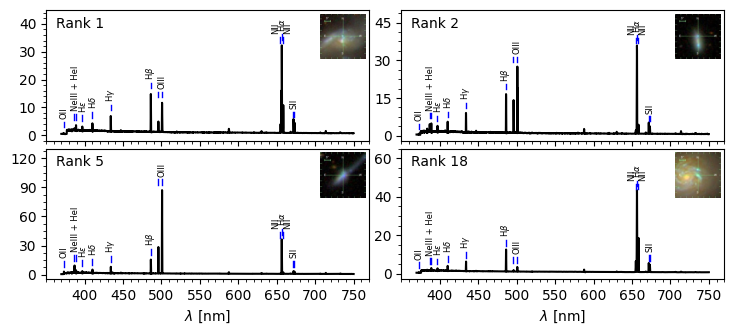

In [89]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=figsize
)

# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# Cluster_1
axs[0, 0], _ = spec_photo_thumbnail(
    axs[0, 0], wave, r1_c1_spec,
    r1_c1_img,
    width_height_image=width_height_image,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 0].text(
    0.03, 0.95,
    f'Rank 1', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 0].set_ylim(-2, 45) 
r1_c1_ticks = [0, 10, 20, 30, 40]
axs[0, 0].set_yticks(r1_c1_ticks)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave, r1_c1_spec,
    indicator_starts=2,
    indicator_height=2,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# ---------------------------------------------- 
axs[0, 1], _ = spec_photo_thumbnail(
    axs[0, 1], wave, r2_c1_spec,
    r2_c1_img,
    width_height_image=width_height_image,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 1].text(
    0.03, 0.95,
    f'Rank 2', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 1].set_ylim(-2, 50) 
r2_c1_ticks = [0, 15, 30, 45]
axs[0, 1].set_yticks(r2_c1_ticks)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave, r2_c1_spec,
    indicator_starts=2,
    indicator_height=2,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------
axs[1, 0], _ = spec_photo_thumbnail(
    axs[1, 0], wave, r5_c1_spec,
    r5_c1_img,
    width_height_image=width_height_image,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 0].text(
    0.03, 0.95,
    f'Rank 5', 
    transform=axs[1, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 0].set_ylim(-5, 130) 
r5_c1_ticks = [0, 30, 60, 90, 120]
axs[1, 0].set_yticks(r5_c1_ticks)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave, r5_c1_spec,
    indicator_starts=5,
    indicator_height=6,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# -------------------------------------------------
axs[1, 1], _ = spec_photo_thumbnail(
    axs[1, 1], wave, r18_c1_spec,
    r18_c1_img,
    width_height_image=width_height_image,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 1].text(
    0.03, 0.95,
    f'Rank 18', 
    transform=axs[1, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 1].set_ylim(-3, 65) 
r18_c1_ticks = [0, 20, 40, 60]
axs[1, 1].set_yticks(r18_c1_ticks)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave, r18_c1_spec,
    indicator_starts=2,
    indicator_height=3,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.1
)

fig.savefig(
    f"{submission_dir}/galaxies_clusters_1.pdf",
    bbox_inches='tight'
)

## Cluster 2 data

In [28]:
rank = 8
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r8_c2_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
r8_c2_img = mpimg.imread(f"{image_dir}/{image_name}")

In [29]:
rank = 11
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r11_c2_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
r11_c2_img = mpimg.imread(f"{image_dir}/{image_name}")

In [30]:
rank = 14
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r14_c2_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
r14_c2_img = mpimg.imread(f"{image_dir}/{image_name}")

In [31]:
rank = 7
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r7_c2_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
r7_c2_img = mpimg.imread(f"{image_dir}/{image_name}")

## Plot cluster 2

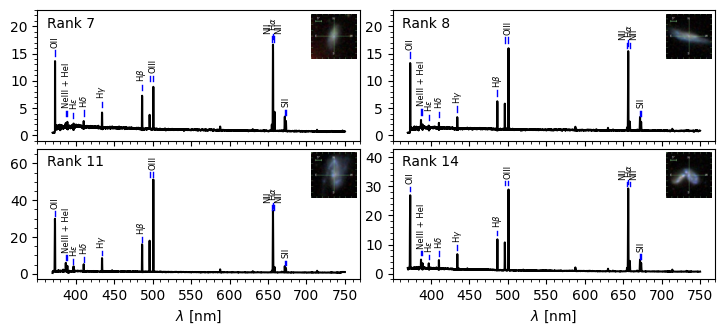

In [94]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=figsize
)
width_height_image = '100%'
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# Cluster_1
axs[0, 0], _ = spec_photo_thumbnail(
    axs[0, 0], wave, r7_c2_spec,
    r7_c2_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 0].text(
    0.03, 0.95,
    f'Rank 7', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 0].set_ylim(-1, 23) 
r7_c2_ticks = [0, 5, 10, 15, 20]
axs[0, 0].set_yticks(r7_c2_ticks)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave, r7_c2_spec,
    indicator_starts=1,
    indicator_height=1,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# ---------------------------------------------- 
axs[0, 1], _ = spec_photo_thumbnail(
    axs[0, 1], wave, r8_c2_spec,
    r8_c2_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 1].text(
    0.03, 0.95,
    f'Rank 8', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 1].set_ylim(-1, 23) 
r8_c2_ticks = [0, 5, 10, 15, 20]
axs[0, 1].set_yticks(r8_c2_ticks)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave, r8_c2_spec,
    indicator_starts=1,
    indicator_height=1,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------
axs[1, 0], _ = spec_photo_thumbnail(
    axs[1, 0], wave, r11_c2_spec,
    r11_c2_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 0].text(
    0.03, 0.95,
    f'Rank 11', 
    transform=axs[1, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 0].set_ylim(-3, 68) 
r11_c2_ticks = [0, 20, 40, 60]
axs[1, 0].set_yticks(r11_c2_ticks)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave, r11_c2_spec,
    indicator_starts=1.5,
    indicator_height=2.5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# -------------------------------------------------
axs[1, 1], _ = spec_photo_thumbnail(
    axs[1, 1], wave, r14_c2_spec,
    r14_c2_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 1].text(
    0.03, 0.95,
    f'Rank 14', 
    transform=axs[1, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 1].set_ylim(-2, 43) 
r14_c2_ticks = [0, 10, 20, 30, 40]
axs[1, 1].set_yticks(r14_c2_ticks)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave, r14_c2_spec,
    indicator_starts=1.5,
    indicator_height=1.5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.1
)

fig.savefig(
    f"{submission_dir}/galaxies_clusters_2.pdf",
    bbox_inches='tight'
)

## Cluster 3 data

In [33]:
rank = 1
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r1_c3_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
r1_c3_img = mpimg.imread(f"{image_dir}/{image_name}")

In [34]:
rank = 5
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r5_c3_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
r5_c3_img = mpimg.imread(f"{image_dir}/{image_name}")

In [35]:
rank = 9
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r9_c3_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
r9_c3_img = mpimg.imread(f"{image_dir}/{image_name}")

In [36]:
rank = 19
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
r19_c3_spec = spectra[idx_spec]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
r19_c3_img = mpimg.imread(f"{image_dir}/{image_name}")

## Plot Cluster 3

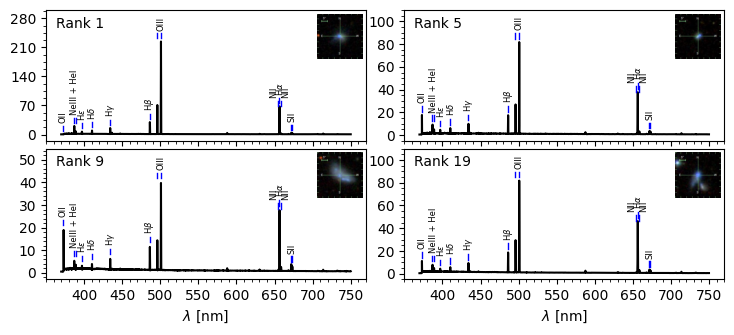

In [101]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=figsize
)
width_height_image = '100%'
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
axs[0, 0], _ = spec_photo_thumbnail(
    axs[0, 0], wave, r1_c3_spec,
    r1_c3_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 0].text(
    0.03, 0.95,
    f'Rank 1', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 0].set_ylim(-15, 300) 
r1_c3_ticks = [0, 70, 140, 210, 280]
axs[0, 0].set_yticks(r1_c3_ticks)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave, r1_c3_spec,
    indicator_starts=8,
    indicator_height=12,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# ---------------------------------------------- 
axs[0, 1], _ = spec_photo_thumbnail(
    axs[0, 1], wave, r5_c3_spec,
    r5_c3_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[0, 1].text(
    0.03, 0.95,
    f'Rank 5', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 1].set_ylim(-5, 110) 
r5_c3_ticks = [0, 20, 40, 60, 80, 100]
axs[0, 1].set_yticks(r5_c3_ticks)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave, r5_c3_spec,
    indicator_starts=3,
    indicator_height=5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------
axs[1, 0], _ = spec_photo_thumbnail(
    axs[1, 0], wave, r9_c3_spec,
    r9_c3_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 0].text(
    0.03, 0.95,
    f'Rank 9', 
    transform=axs[1, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 0].set_ylim(-3, 55) 
r9_c3_ticks = [0, 10, 20, 30, 40, 50]
axs[1, 0].set_yticks(r9_c3_ticks)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave, r9_c3_spec,
    indicator_starts=2,
    indicator_height=2.5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# -------------------------------------------------
axs[1, 1], _ = spec_photo_thumbnail(
    axs[1, 1], wave, r19_c3_spec,
    r19_c3_img,
    bbox_to_anchor=bbox_to_anchor,
    add_image=True,
)
axs[1, 1].text(
    0.03, 0.95,
    f'Rank 19', 
    transform=axs[1, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[1, 1].set_ylim(-5, 110) 
r19_c3_ticks = [0, 20, 40, 60, 80, 100]
axs[1, 1].set_yticks(r19_c3_ticks)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave, r19_c3_spec,
    indicator_starts=3,
    indicator_height=5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# -------------------------------------------------

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.12
)

fig.savefig(
    f"{submission_dir}/galaxies_clusters_3.pdf",
    bbox_inches='tight'
)